In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [ ]:
param_grid = {
    'model_params.hidden_layers': [(128, 64, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.5],
    'learning_rate': [0.0001],
    'batch_size': [32, 64],
    'epochs': [300],
    'l2_reg': [0.1]
}


In [6]:
feature_df.fillna(-1, inplace=True)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(128, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0.5], 'learning_rate': [0.0001], 'batch_size': [32, 64], 'epochs': [300], 'l2_reg': [0.1]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


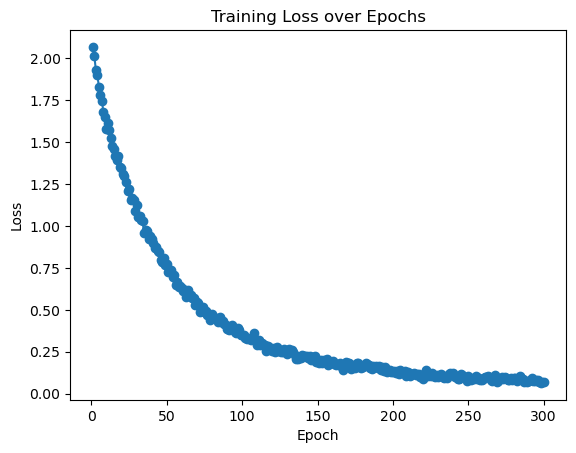

Final training loss: 0.06692914071873315
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


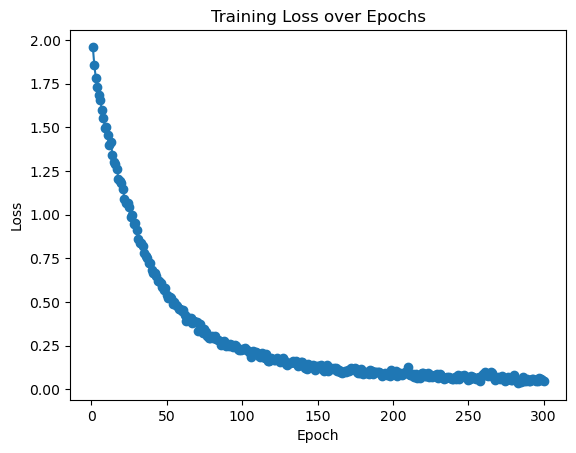

Final training loss: 0.04746923070251568
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


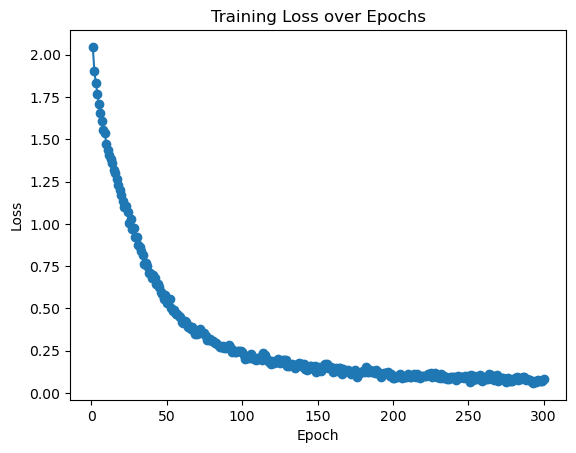

Final training loss: 0.0820042067452481
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


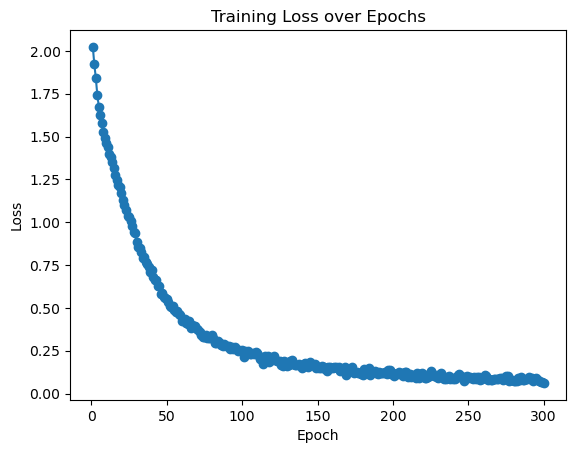

Final training loss: 0.06200024746545126
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


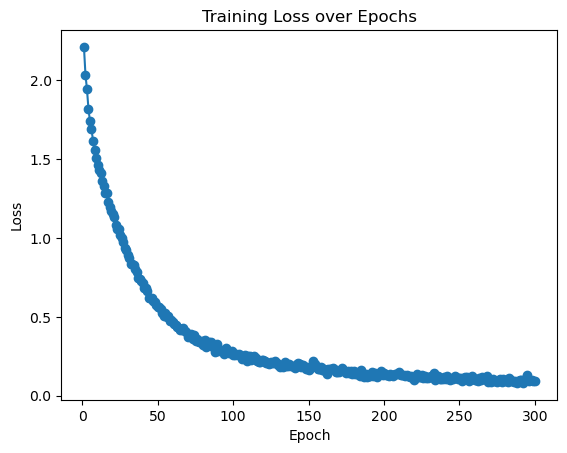

Final training loss: 0.09078911278480874
[TorchWrapper] Using device: mps


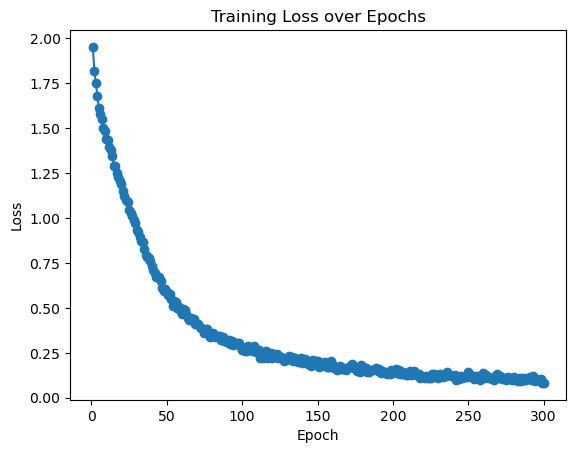

Final training loss: 0.08240028741515071
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2431077694235589, 'home_goals_valid_precision': 0.1587831259956305, 'home_goals_test_accuracy': 0.23308270676691728, 'home_goals_test_precision': 0.1339505765107627, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_eq_1_accuracy': 1.0, 'home_goals_train_eq_1_accuracy_std': 0.0, 'home_goals_train_eq_1_precision': 1.0, 'home_goals_train_eq_1_precision_std': 0.0, 'home_goals_train_eq_2_accuracy': 1.0, 'home_goals_train_eq_2_accuracy_std': 0.0, 'home_goals_train_eq_2_precision': 1.0, 'home_goals_train_eq_2_precision_std': 0.0, 'home_goals_train_eq_3_accuracy': 1.0, 'home_goals_train_eq_3_accuracy_std': 0.0, 'home_goals_train_eq_3_precision': 1.0, 'home_goals_train_eq_3_precision_std': 0.0, 'home_goals_train_eq_4_a

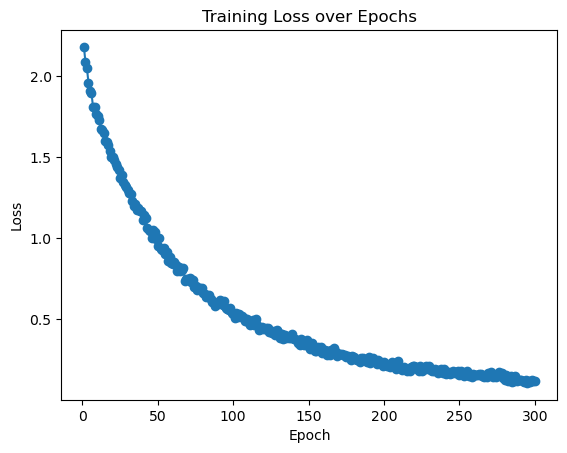

Final training loss: 0.12267143247569713
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


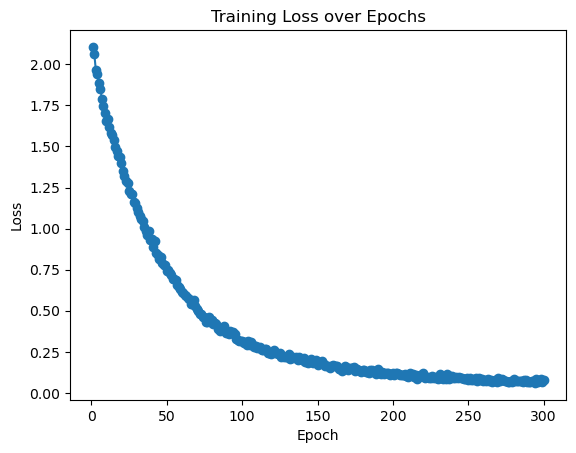

Final training loss: 0.07855712415132307
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


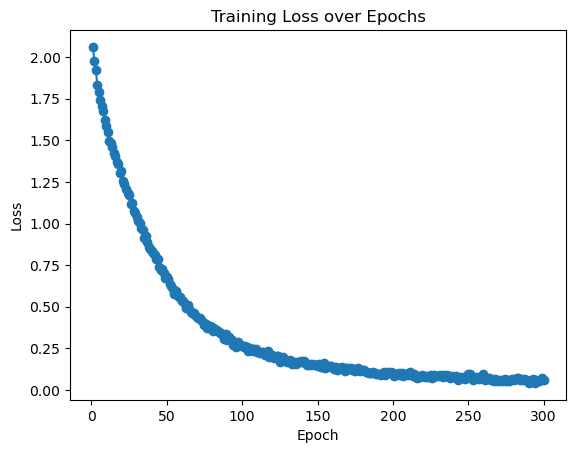

Final training loss: 0.05717613498245365
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


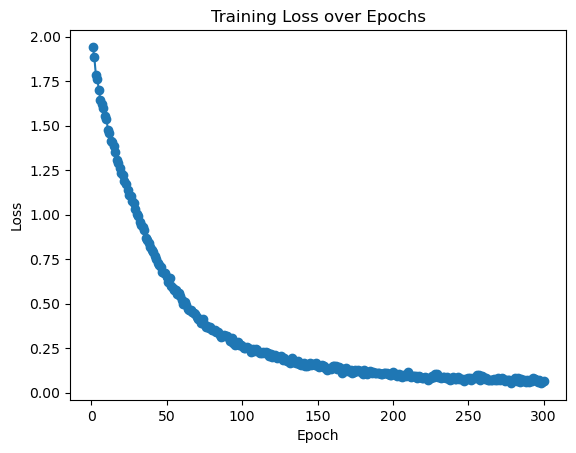

Final training loss: 0.06374972985875338
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


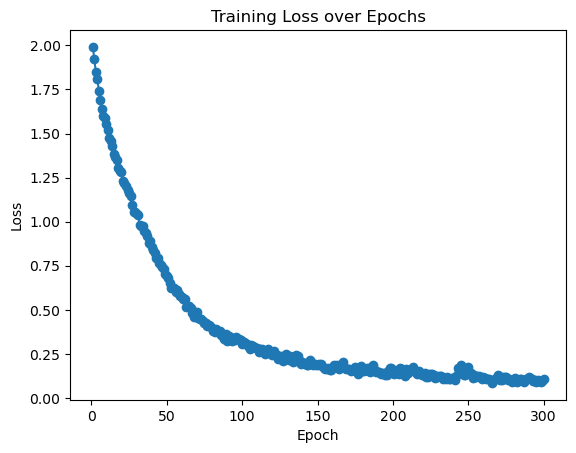

Final training loss: 0.11017515843075917
[TorchWrapper] Using device: mps


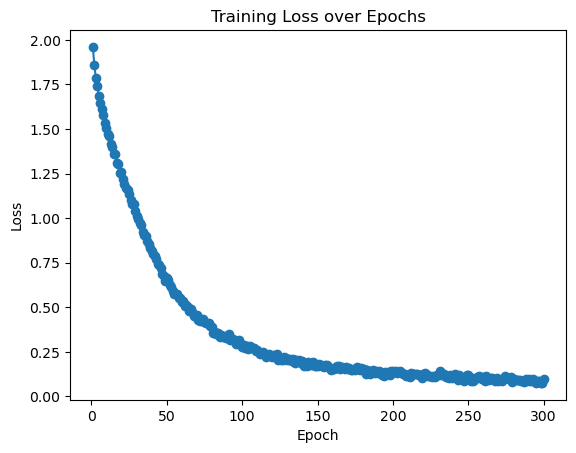

Final training loss: 0.09859227180580547
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.25162907268170426, 'home_goals_valid_precision': 0.17866892303014087, 'home_goals_test_accuracy': 0.2744360902255639, 'home_goals_test_precision': 0.16949866484818873, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_eq_1_accuracy': 1.0, 'home_goals_train_eq_1_accuracy_std': 0.0, 'home_goals_train_eq_1_precision': 1.0, 'home_goals_train_eq_1_precision_std': 0.0, 'home_goals_train_eq_2_accuracy': 1.0, 'home_goals_train_eq_2_accuracy_std': 0.0, 'home_goals_train_eq_2_precision': 1.0, 'home_goals_train_eq_2_precision_std': 0.0, 'home_goals_train_eq_3_accuracy': 1.0, 'home_goals_train_eq_3_accuracy_std': 0.0, 'home_goals_train_eq_3_precision': 1.0, 'home_goals_train_eq_3_precision_std': 0.0, 'home_goals_train_eq_4

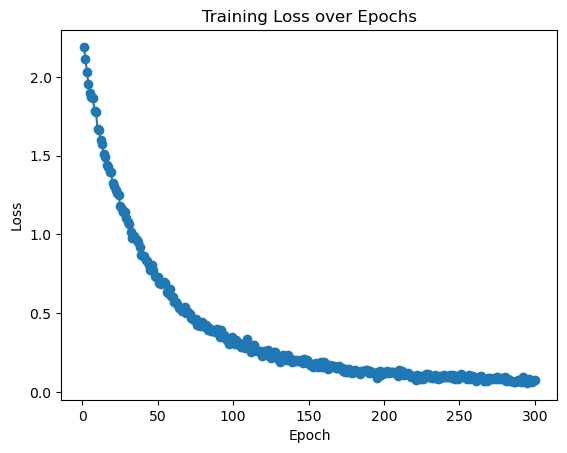

Final training loss: 0.07933372887490985
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


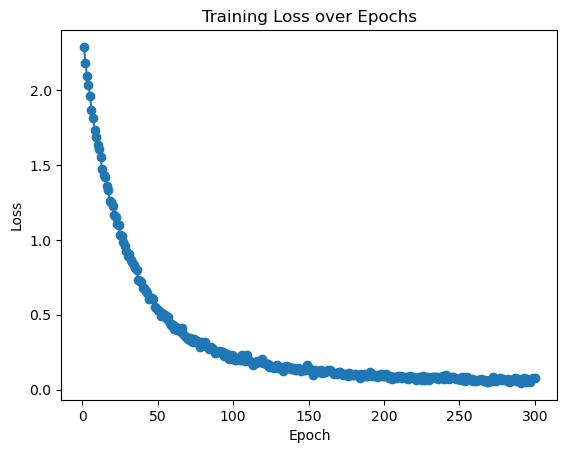

Final training loss: 0.07975176024369728
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


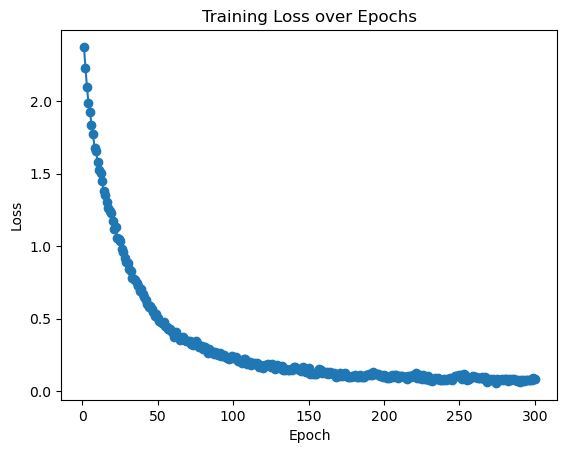

Final training loss: 0.07992441849526308
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


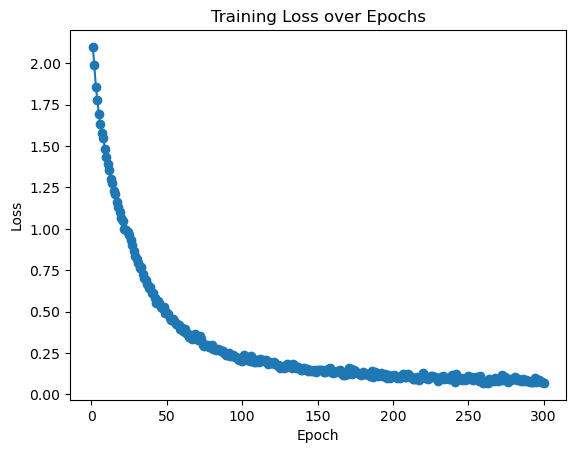

Final training loss: 0.07072135242155023
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


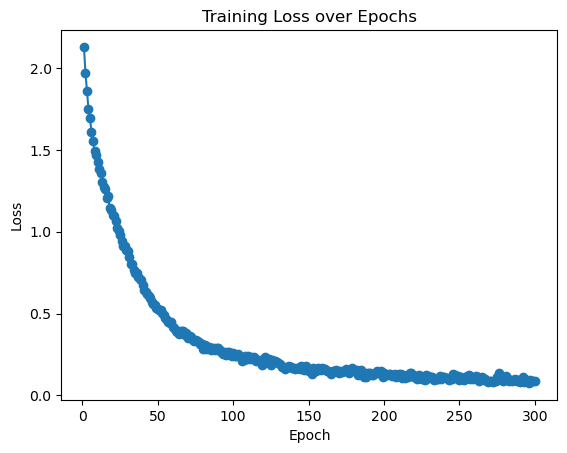

Final training loss: 0.08438467405792466
[TorchWrapper] Using device: mps


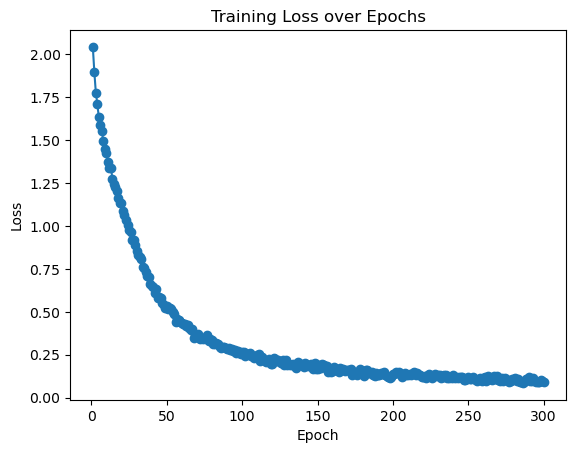

Final training loss: 0.09046615342747298
{'away_goals_train_accuracy': 0.9976608187134502, 'away_goals_train_precision': 0.8274184478573361, 'away_goals_valid_accuracy': 0.2776942355889724, 'away_goals_valid_precision': 0.14257588854820824, 'away_goals_test_accuracy': 0.2894736842105263, 'away_goals_test_precision': 0.14226266347307626, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_eq_1_accuracy': 0.9997744360902256, 'away_goals_train_eq_1_accuracy_std': 0.0002790859329739385, 'away_goals_train_eq_1_precision': 0.9993148304741165, 'away_goals_train_eq_1_precision_std': 0.0008482156665083711, 'away_goals_train_eq_2_accuracy': 0.9996658312447785, 'away_goals_train_eq_2_accuracy_std': 0.0006683375104427736, 'away_goals_train_eq_2_precision': 0.9984732824427482, 'away_goals_train_eq_2_precision_std': 0.0030534351145038215, 'away_goals_train_eq_3_accu

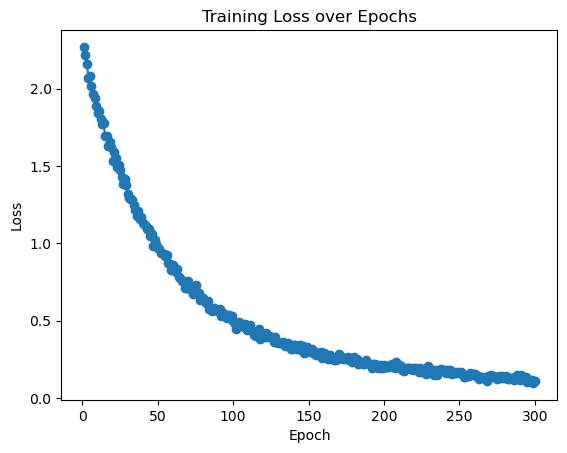

Final training loss: 0.10958073383435271
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


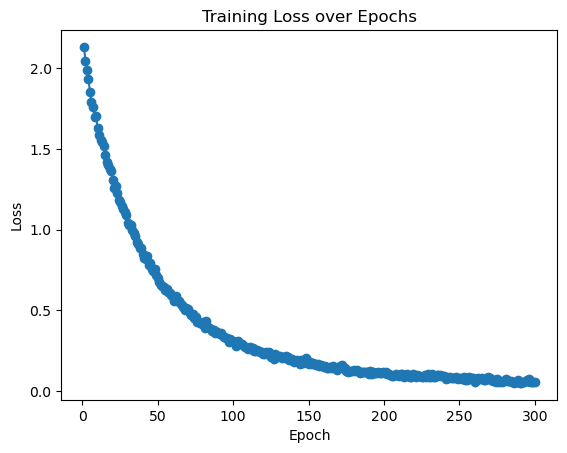

Final training loss: 0.05502039285605414
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


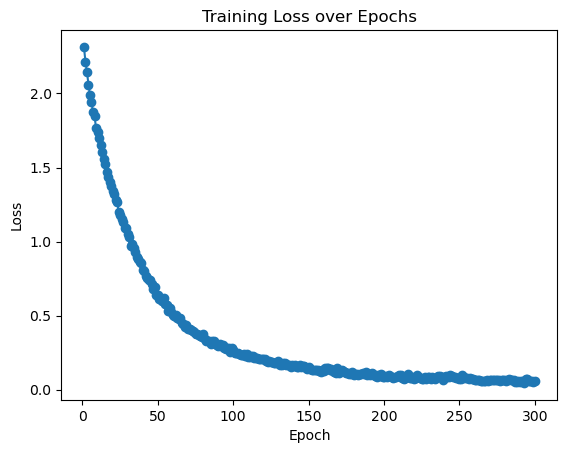

Final training loss: 0.057602683399666225
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


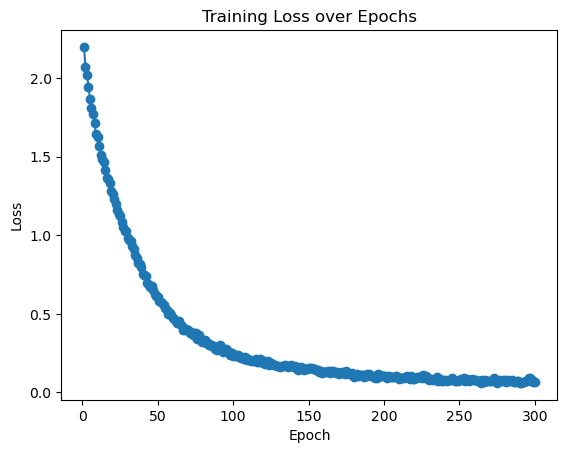

Final training loss: 0.06552513602906301
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 300, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps


KeyboardInterrupt: 

In [7]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    key_columns=TRAINGING_CONFIG['key_columns'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    save_model_path=TRAINGING_CONFIG['save_model_path']
)

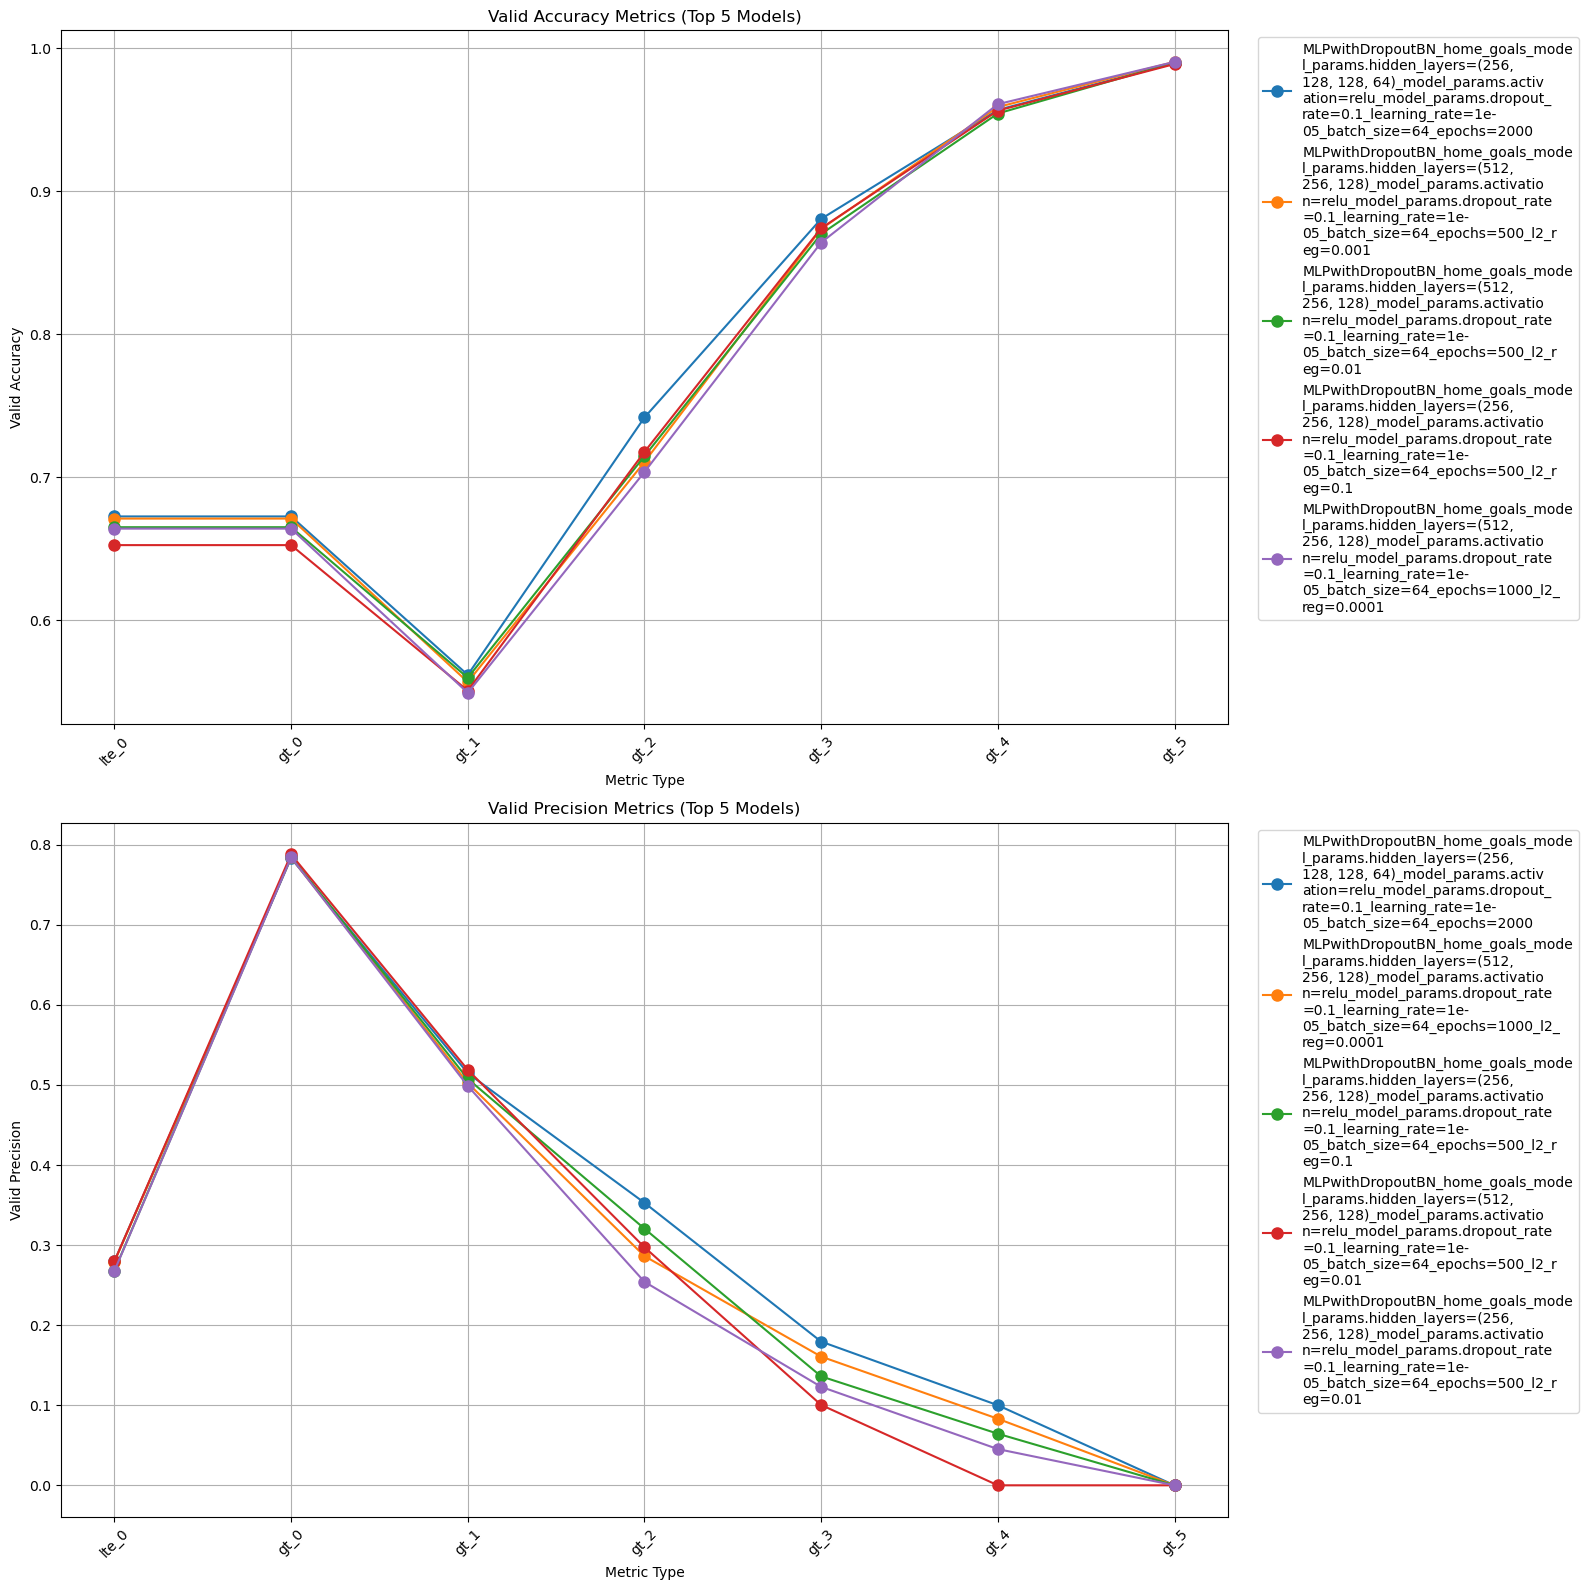

In [ ]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [ ]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_model_params.hidden_layers=(256, 128, 128, 64)_model_params.activation=relu_model_params.dropout_rate=0.1_learning_rate=1e-05_batch_size=64_epochs=2000",
                         target_col="away_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

NameError: name 'plot_run_metrics_by_split' is not defined

In [ ]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers= '(512, 256, 256, 128, 128)' and params.model_params.activation= 'relu' and params.model_params.dropout_rate= '0' and params.learning_rate= '1e-05' and params.batch_size= '64' and params.epochs= '5000'
No runs found with model_name 'MLPwithDropoutBN' and params {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}.
